# Financial Consumer Complaints Analysis

In this Jupyter Notebook, we'll analyze consumers' complaints on financial products & services for Bank of America from 2017 to 2023.
We will try to figure out the most frequent customer complaints, how companies usually responded to them, and what can be done to improve customers' safety and experience.

The dataset used for this project is publicly available on [Maven Analytics](https://mavenanalytics.io/data-playground/financial-consumer-complaints) and was sourced from the Consumer Financial Protection Bureau ([CFPB](https://www.consumerfinance.gov/data-research/consumer-complaints/#download-the-data)).

##  Part 1: Importing the Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import prettytable
prettytable.DEFAULT = 'DEFAULT'
%load_ext sql
%matplotlib inline

In [ ]:
data_dict = pd.read_csv('ConsumerComplaints_DataDictionary.csv')
data_dict

,Field,Description
0,Complaint ID,The unique identification number for a complaint
1,Submitted via,How the complaint was submitted to the CFPB
2,Date submitted,The date the CFPB received the complaint
3,Date received,The date the CFPB sent the complaint to the co...
4,State,The state of the mailing address provided by t...
5,Product,The type of product the consumer identified in...
6,Sub-product,The type of sub-product the consumer identifie...
7,Issue,The issue the consumer identified in the compl...
8,Sub-issue,The sub-issue the consumer identified in the c...
9,Company public response,"The company's optional, public-facing response..."


In [ ]:
df = pd.read_excel('Consumer_Complaints.xlsx')
df.head()

,Complaint ID,Submitted via,Date submitted,Date received,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,Timely response?
0,4848023,Referral,2021-10-24,2021-10-27,NY,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an exis...,NaN,Company has responded to the consumer and the ...,Closed with explanation,Yes
1,3621464,Web,2020-04-24,2020-04-24,FL,"Money transfer, virtual currency, or money ser...",Refund anticipation check,Lost or stolen check,NaN,Company has responded to the consumer and the ...,Closed with monetary relief,Yes
2,5818349,Web,2022-07-27,2022-07-27,CA,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Account information incorrect,Company has responded to the consumer and the ...,Closed with explanation,Yes
3,7233015,Referral,2023-07-10,2023-07-11,CA,Credit card or prepaid card,General-purpose prepaid card,Problem getting a card or closing an account,"Trouble getting, activating, or registering a ...",NaN,In progress,NaN
4,5820224,Referral,2022-07-27,2022-07-28,VA,Credit card or prepaid card,General-purpose credit card or charge card,Closing your account,Company closed your account,Company has responded to the consumer and the ...,Closed with explanation,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62516 entries, 0 to 62515
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Complaint ID                  62516 non-null  int64         
 1   Submitted via                 62516 non-null  object        
 2   Date submitted                62516 non-null  datetime64[ns]
 3   Date received                 62516 non-null  datetime64[ns]
 4   State                         62516 non-null  object        
 5   Product                       62516 non-null  object        
 6   Sub-product                   62509 non-null  object        
 7   Issue                         62516 non-null  object        
 8   Sub-issue                     51658 non-null  object        
 9   Company public response       60341 non-null  object        
 10  Company response to consumer  62516 non-null  object        
 11  Timely response?            

## Part 2: Data Wrangling

In [ ]:
df = df.drop_duplicates()

In [ ]:
objects = df.select_dtypes('object').columns
for obj in objects:
  print(df[obj].value_counts())
  print()

Submitted via
Web             45423
Referral        10766
Phone            4684
Postal mail      1318
Fax               233
Web Referral       90
Email               2
Name: count, dtype: int64

State
CA    13709
FL     6488
TX     4686
NY     4442
GA     2921
NJ     2664
IL     2270
MA     2141
MD     1959
VA     1731
NC     1717
PA     1676
WA     1530
AZ     1516
MI     1395
NV     1221
CT     1097
SC      822
TN      758
OH      731
MO      674
OR      620
CO      576
MN      382
DC      353
IN      316
KS      311
OK      293
WI      291
AL      269
DE      268
AR      266
RI      249
LA      246
NM      219
UT      201
NH      199
KY      157
IA      154
ME      152
MS      141
ID      122
HI      111
AK      110
NE       83
WV       77
MT       70
VT       54
SD       34
ND       22
WY       22
Name: count, dtype: int64

Product
Checking or savings account                                                     24814
Credit card or prepaid card                                       

In [ ]:
for obj in objects:
  df[obj] = df[obj].str.strip().str.lower()
  df = df.drop_duplicates()
df.shape

(62516, 12)

In [ ]:
df.columns = df.columns.str.lower()

In [ ]:
df.isna().sum()

,0
complaint id,0
submitted via,0
date submitted,0
date received,0
state,0
product,0
sub-product,7
issue,0
sub-issue,10858
company public response,2175


In [ ]:
df[['sub-issue', 'company public response', 'timely response?']] = df[['sub-issue', 'company public response', 'timely response?']].fillna('unknown')

In [ ]:
df = df.dropna()

In [ ]:
df.describe()

,complaint id,date submitted,date received
count,6.250900e+04,62509,62509
mean,4.512695e+06,2020-11-24 16:24:35.269161728,2020-11-25 21:48:24.868098816
min,2.471340e+06,2017-05-01 00:00:00,2017-05-01 00:00:00
25%,3.254035e+06,2019-05-22 00:00:00,2019-05-28 00:00:00
50%,4.178389e+06,2021-03-02 00:00:00,2021-03-03 00:00:00
75%,5.771325e+06,2022-07-14 00:00:00,2022-07-15 00:00:00
max,7.458912e+06,2023-08-28 00:00:00,2023-08-28 00:00:00
std,1.442963e+06,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 62509 entries, 0 to 62515
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   complaint id                  62509 non-null  int64         
 1   submitted via                 62509 non-null  object        
 2   date submitted                62509 non-null  datetime64[ns]
 3   date received                 62509 non-null  datetime64[ns]
 4   state                         62509 non-null  object        
 5   product                       62509 non-null  object        
 6   sub-product                   62509 non-null  object        
 7   issue                         62509 non-null  object        
 8   sub-issue                     62509 non-null  object        
 9   company public response       62509 non-null  object        
 10  company response to consumer  62509 non-null  object        
 11  timely response?              625

We have removed the duplicates, ensured there are no incorrect string values in the categorical columns, dealed with missing values, ensured there are no outliers in date columns, and we are still left with over 62.5 thousand rows of data.

This sample is large enough to analyze and derive useful conclusions from.

## Part 3: Exploratory Data Analysis

In this analysis, we will try to answer the following questions:
- Which products and subproducts did the customers complain about the most?
- What issues were reported most often?
- How has the frequency of complaints changed over time?
- On average, how fast have the companies been receiving customer complaints after submission?
- How are the client complaints typically resolved?
- Which issues most frequently did not receive a public response from the companies? Why?
- For which issues and complaints were the company responses not timely, and why?

In [ ]:
from sqlalchemy import create_engine

con = sqlite3.connect('consumer_complaints.db')
%sql sqlite:///consumer_complaints.db
engine = create_engine('sqlite:///consumer_complaints.db')
df.to_sql('complaints', engine, if_exists='replace', index=False)

62509

In [ ]:
%%sql
select * from complaints limit 5

 * sqlite:///consumer_complaints.db
Done.


complaint id,submitted via,date submitted,date received,state,product,sub-product,issue,sub-issue,company public response,company response to consumer,timely response?
4848023,referral,2021-10-24 00:00:00.000000,2021-10-27 00:00:00.000000,ny,mortgage,conventional home mortgage,applying for a mortgage or refinancing an existing mortgage,unknown,company has responded to the consumer and the cfpb and chooses not to provide a public response,closed with explanation,yes
3621464,web,2020-04-24 00:00:00.000000,2020-04-24 00:00:00.000000,fl,"money transfer, virtual currency, or money service",refund anticipation check,lost or stolen check,unknown,company has responded to the consumer and the cfpb and chooses not to provide a public response,closed with monetary relief,yes
5818349,web,2022-07-27 00:00:00.000000,2022-07-27 00:00:00.000000,ca,"credit reporting, credit repair services, or other personal consumer reports",credit reporting,incorrect information on your report,account information incorrect,company has responded to the consumer and the cfpb and chooses not to provide a public response,closed with explanation,yes
7233015,referral,2023-07-10 00:00:00.000000,2023-07-11 00:00:00.000000,ca,credit card or prepaid card,general-purpose prepaid card,problem getting a card or closing an account,"trouble getting, activating, or registering a card",unknown,in progress,unknown
5820224,referral,2022-07-27 00:00:00.000000,2022-07-28 00:00:00.000000,va,credit card or prepaid card,general-purpose credit card or charge card,closing your account,company closed your account,company has responded to the consumer and the cfpb and chooses not to provide a public response,closed with explanation,yes


In [ ]:
%%sql
SELECT
  product,
  `sub-product`,
  count(*) as complaint_count
FROM
  complaints
GROUP BY
  product
ORDER BY
  complaint_count desc
LIMIT 10

 * sqlite:///consumer_complaints.db
Done.


product,sub-product,complaint_count
checking or savings account,checking account,24807
credit card or prepaid card,general-purpose prepaid card,16197
"credit reporting, credit repair services, or other personal consumer reports",credit reporting,7710
mortgage,conventional home mortgage,6601
"money transfer, virtual currency, or money service",refund anticipation check,3453
debt collection,credit card debt,2736
vehicle loan or lease,loan,633
"payday loan, title loan, or personal loan",personal line of credit,333
student loan,private student loan,39


As we can see, customers most often complained about:
  1. Checking accounts
  2. General-purpose prepaid cards
  3. Credit reporting
  4. Conventional home mortgages
  5. Refund anticipations checks
  6. Credit card debt.

These products account for the vast majority of customer complaints, and thus fixing them is essential to reduce churn and maintain competitiveness in the market.

But why were these products reported most often? We will adjust the SQL query and find the most common issues found related to them.


In [ ]:
%%sql
SELECT
  product,
  `sub-product`,
  issue,
  `sub-issue`,
  count(*) as complaint_count
FROM
  complaints
WHERE
  `sub-issue` != 'unknown'
GROUP BY
  issue
ORDER BY
  complaint_count desc
LIMIT 20

 * sqlite:///consumer_complaints.db
Done.


product,sub-product,issue,sub-issue,complaint_count
checking or savings account,checking account,managing an account,deposits and withdrawals,15109
"credit reporting, credit repair services, or other personal consumer reports",credit reporting,incorrect information on your report,account information incorrect,4926
credit card or prepaid card,general-purpose credit card or charge card,problem with a purchase shown on your statement,card was charged for something you did not purchase with the card,4415
checking or savings account,checking account,closing an account,funds not received from closed account,2953
checking or savings account,checking account,opening an account,account opened as a result of fraud,2725
checking or savings account,checking account,problem with a lender or other company charging your account,money was taken from your account on the wrong day or for the wrong amount,2493
"credit reporting, credit repair services, or other personal consumer reports",credit reporting,problem with a credit reporting company's investigation into an existing problem,problem with personal statement of dispute,1874
credit card or prepaid card,general-purpose credit card or charge card,getting a credit card,card opened as result of identity theft or fraud,1867
credit card or prepaid card,general-purpose credit card or charge card,"other features, terms, or problems",problem with customer service,1633
"credit reporting, credit repair services, or other personal consumer reports",credit reporting,improper use of your report,reporting company used your report improperly,1624


Let us now visualize what we've found so far for easier reading and comprehension.

Text(0, 0.5, 'Product')

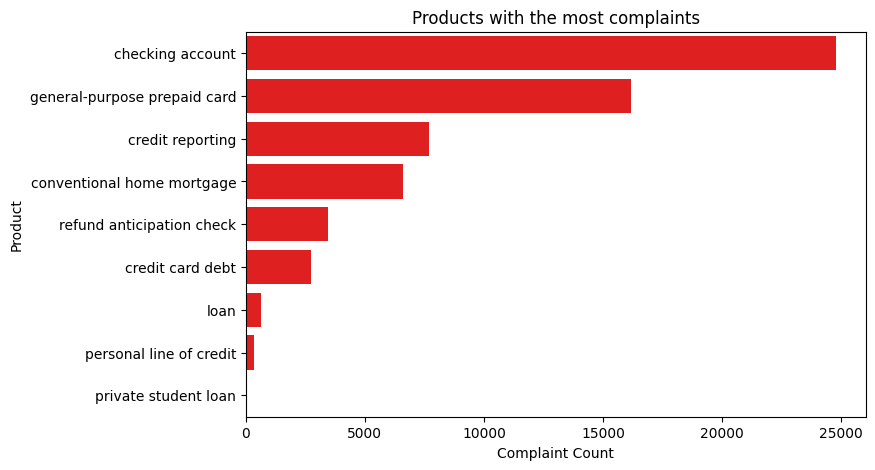

In [ ]:
query = """
SELECT
  product,
  `sub-product` as sub_product,
  count(*) as complaint_count
FROM
  complaints
GROUP BY
  product
ORDER BY
  complaint_count desc
LIMIT 10
"""
insight = pd.read_sql(query, con)
fig, ax = plt.subplots(1,1, figsize = (8,5))
sns.barplot(x = 'complaint_count', y = 'sub_product', data=insight, color='red', ax = ax)
ax.set_title("Products with the most complaints")
ax.set_xlabel('Complaint Count')
ax.set_ylabel('Product')

Text(0, 0.5, 'Issue')

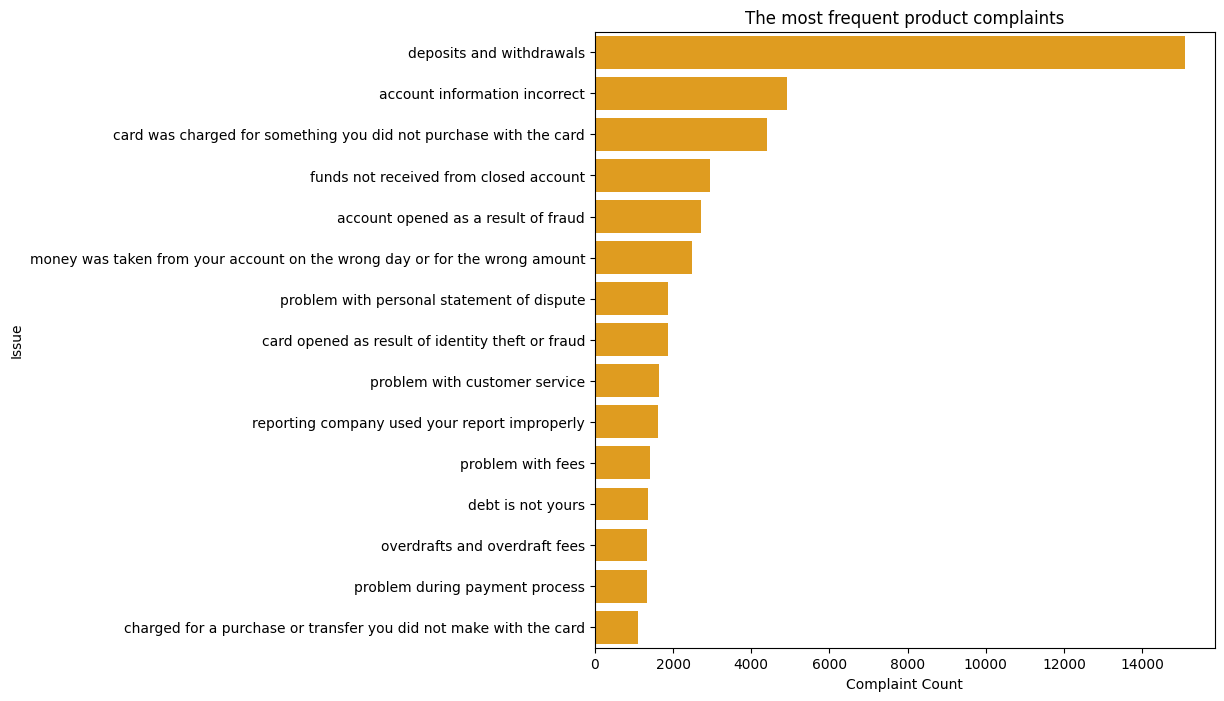

In [ ]:
query = """
SELECT
  product,
  `sub-product`,
  issue,
  `sub-issue` as sub_issue,
  count(*) as complaint_count
FROM
  complaints
WHERE
  sub_issue != 'unknown'
GROUP BY
  issue
ORDER BY
  complaint_count desc
LIMIT 15
"""
insight = pd.read_sql(query, con)
fig, ax = plt.subplots(1,1,figsize = (8,8))
sns.barplot(data = insight, x = 'complaint_count', y = 'sub_issue', color='orange', ax = ax)
ax.set_title("The most frequent product complaints")
ax.set_xlabel('Complaint Count')
ax.set_ylabel('Issue')

Clients most frequently complained about:
- Deposits and withdrawals
- Incorrect account information
- Cards being charged when the client did not purchase anything
- Funds not being received from closed accounts
- Accounts being opened as a result of fraud.

Now, let's see how the companies have most frequently responded to customer complaints.

In [ ]:
%%sql
SELECT
  `company public response`,
  `company response to consumer`,
  count(*) as complaint_count
FROM
  complaints
GROUP BY
  `company public response`,
  `company response to consumer`
ORDER BY
  complaint_count desc
LIMIT 10

 * sqlite:///consumer_complaints.db
Done.


company public response,company response to consumer,complaint_count
company has responded to the consumer and the cfpb and chooses not to provide a public response,closed with explanation,40553
company has responded to the consumer and the cfpb and chooses not to provide a public response,closed with monetary relief,14522
company has responded to the consumer and the cfpb and chooses not to provide a public response,closed with non-monetary relief,5229
unknown,in progress,1494
unknown,closed with explanation,469
unknown,closed with monetary relief,164
unknown,closed with non-monetary relief,40
unknown,closed,8
company believes the complaint provided an opportunity to answer consumer's questions,closed with explanation,6
company believes it acted appropriately as authorized by contract or law,closed with explanation,5


- In most cases, companies have responded to the consumers and CFPB, but chose not to address the issue publicly.
- Additionally, the companies have responded with explanation and monetary relief in over 90% of cases.
- We will no visualize the companies's most frequent responses to consumers.

Text(0, 0.5, 'Response')

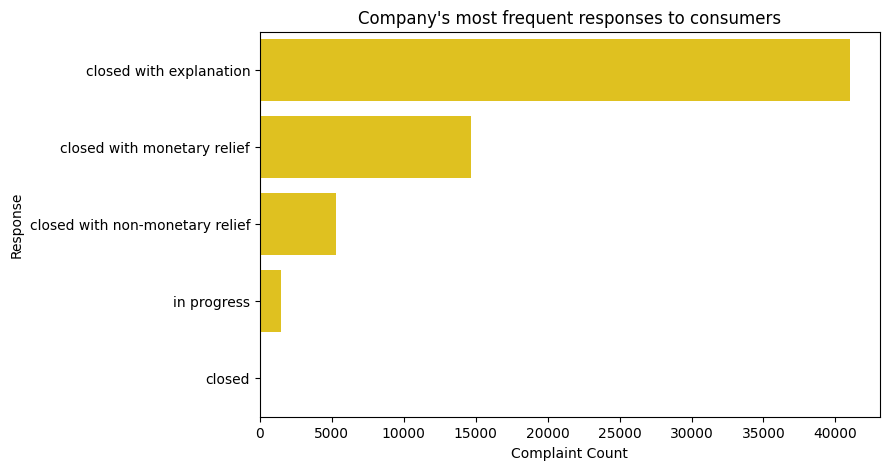

In [ ]:
query = """
SELECT
  `company response to consumer`,
  count(*) as complaint_count
FROM
  complaints
GROUP BY
  `company response to consumer`
ORDER BY
  complaint_count desc
LIMIT 5
"""
insight = pd.read_sql(query, con)
fig, ax = plt.subplots(1,1,figsize = (8,5))
sns.barplot(data = insight, x = 'complaint_count', y = 'company response to consumer', color='gold', ax = ax)
ax.set_title("Company's most frequent responses to consumers")
ax.set_xlabel('Complaint Count')
ax.set_ylabel('Response')

Text(0, 0.5, 'Complaint Count')

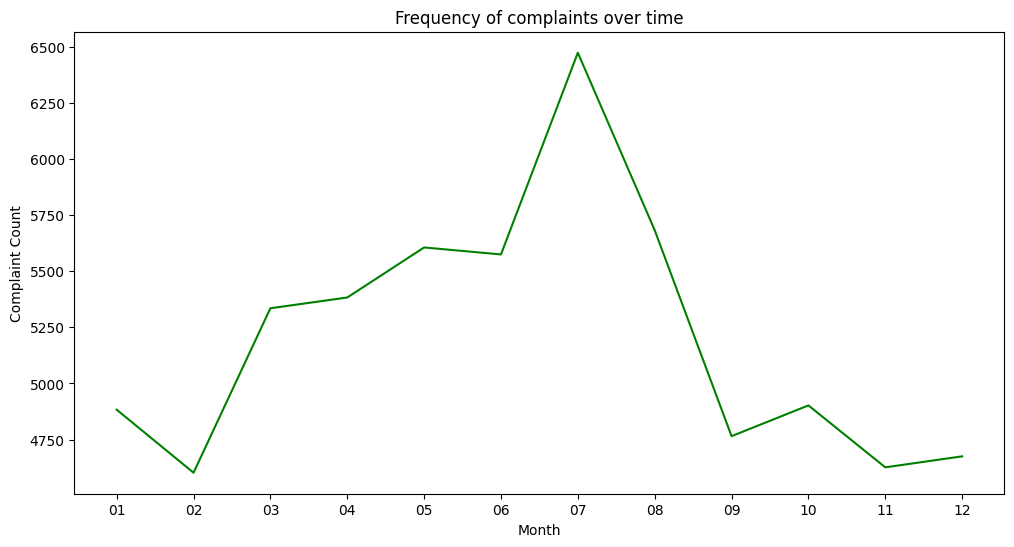

In [ ]:
query = """
SELECT
  strftime('%m', `date submitted`) as date_submitted,
  count(*) as complaint_count
FROM
  complaints
GROUP BY
  date_submitted
ORDER BY
  date_submitted
"""
insight = pd.read_sql(query, con)
fig, ax = plt.subplots(1,1,figsize = (12,6))
sns.lineplot(data = insight, x = 'date_submitted', y = 'complaint_count', color='green', ax = ax)
ax.set_title("Frequency of complaints over time")
ax.set_xlabel('Month')
ax.set_ylabel('Complaint Count')

- On average, the number of customer complaints spikes in July, but remains relatively low during autumn and winter months.
- This is likely because the overall number of transactions is high in summer (due to active purchases and vacations), and complaints are thus more likely to arise in this period.

In [ ]:
%%sql
SELECT
  avg(julianday(`date received`) - julianday(`date submitted`)) as avg_response_time
FROM
  complaints

 * sqlite:///consumer_complaints.db
Done.


avg_response_time
1.2248796173351038


As we can see, on average, it takes 1.2 days for companies to receive customer complaints from the CFPB.

Now, we'll investigate which issues companies have not provided a public or timely response to.

In [ ]:
%%sql
SELECT
  issue,
  `sub-issue`,
  count(*) as complaint_count
FROM
  complaints
WHERE
  `company public response` = 'unknown'
GROUP BY
  issue
ORDER BY
  complaint_count desc
LIMIT 10

 * sqlite:///consumer_complaints.db
Done.


issue,sub-issue,complaint_count
managing an account,problem using a debit or atm card,546
incorrect information on your report,information belongs to someone else,161
problem with a lender or other company charging your account,transaction was not authorized,129
problem with a purchase shown on your statement,card was charged for something you did not purchase with the card,117
opening an account,account opened as a result of fraud,117
closing an account,can't close your account,106
"other features, terms, or problems",other problem,82
improper use of your report,credit inquiries on your report that you don't recognize,82
problem with a credit reporting company's investigation into an existing problem,their investigation did not fix an error on your report,76
problem caused by your funds being low,non-sufficient funds and associated fees,71


Text(0, 0.5, 'Issue')

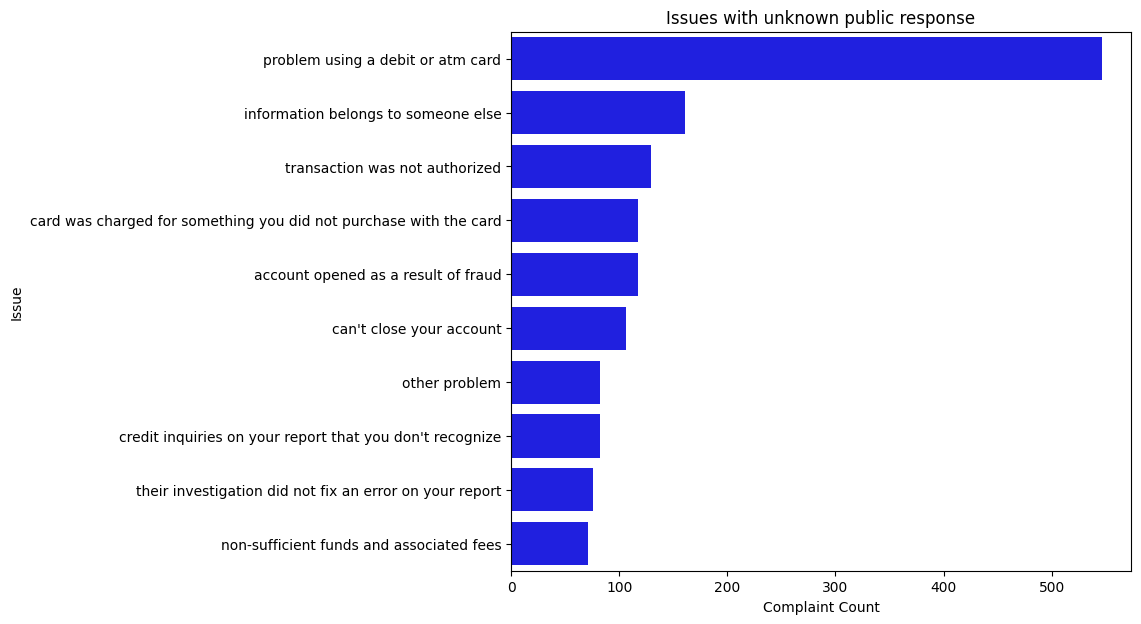

In [ ]:
query = """
SELECT
  issue,
  `sub-issue` as sub_issue,
  count(*) as complaint_count
FROM
  complaints
WHERE
  `company public response` = 'unknown'
GROUP BY
  issue
ORDER BY
  complaint_count desc
LIMIT 10
"""
insight = pd.read_sql(query, con)
fig, ax = plt.subplots(1,1,figsize=(8,7))
sns.barplot(data = insight, x = 'complaint_count', y = 'sub_issue', orient = 'h', color='blue', ax = ax)
ax.set_title('Issues with unknown public response')
ax.set_xlabel('Complaint Count')
ax.set_ylabel('Issue')

In [ ]:
%%sql
SELECT
  issue,
  `sub-issue`,
  count(*) as complaint_count
FROM
  complaints
WHERE
  `timely response?` = 'unknown' or
  `timely response?` = 'no'
GROUP BY
  issue
ORDER BY
  complaint_count desc
LIMIT 10

 * sqlite:///consumer_complaints.db
Done.


issue,sub-issue,complaint_count
managing an account,problem using a debit or atm card,877
incorrect information on your report,information belongs to someone else,402
problem with a purchase shown on your statement,card was charged for something you did not purchase with the card,260
opening an account,account opened as a result of fraud,207
closing an account,can't close your account,199
problem with a lender or other company charging your account,transaction was not authorized,192
problem with a credit reporting company's investigation into an existing problem,their investigation did not fix an error on your report,148
improper use of your report,credit inquiries on your report that you don't recognize,142
"other features, terms, or problems",add-on products and services,137
attempts to collect debt not owed,debt is not yours,133


Text(0, 0.5, 'Issue')

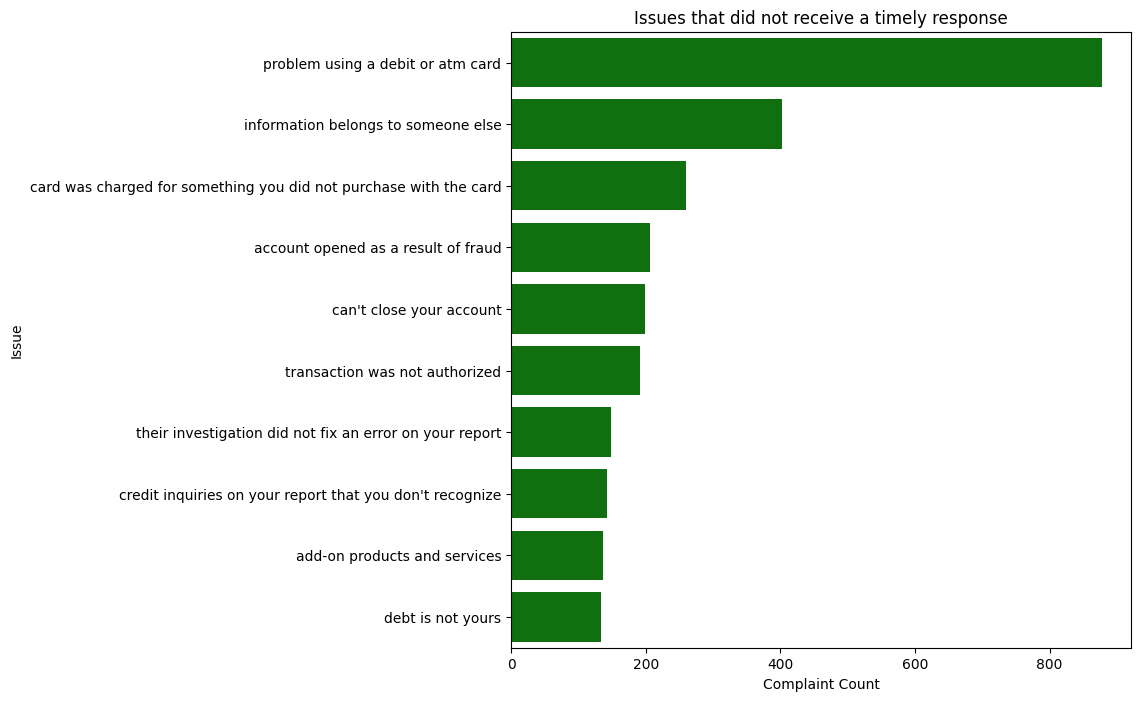

In [ ]:
query = """
SELECT
  issue,
  `sub-issue` as sub_issue,
  count(*) as complaint_count
FROM
  complaints
WHERE
  `timely response?` = 'unknown' or
  `timely response?` = 'no'
GROUP BY
  issue
ORDER BY
  complaint_count desc
LIMIT 10
"""
insight = pd.read_sql(query, con)
fig, ax = plt.subplots(1,1,figsize=(8,8))
sns.barplot(data = insight, x = 'complaint_count', y = 'sub_issue', color='green', ax = ax)
ax.set_title("Issues that did not receive a timely response")
ax.set_xlabel('Complaint Count')
ax.set_ylabel('Issue')

In most cases, companies did not provide a timely response to consumers for problems related to:
- Using a debit or ATM card
- Information belonging to someone else
- Unauthorized transactions
- Opened accounts as a result of fraud.

This suggests that current financial services have security issues that should be fixed and investigated to improve customer retention and safety.

## Conclusion

After conducting the data analysis, we've derived multiple insights:
- Most consumer complaints on financial products & services are related to fraud, incorrect account information, and problems related to deposits and withdrawals.
- Consumers complained the most about checking accounts, general purpose prepaid cards, credit reporting, conventional home mortgage, and refund anticipation checks.
- The frequency of consumer complaints peaks in summer in July, then remains relatively low in winter and autumn.
- On average, it takes companies about 1.2 days to receive consumer complaints from CFPB.
- Companies most frequently responded to consumer problems through providing an explanation or monetary relief.
  - It is worth noting that most companies do not provide a public response to customer's complaints.
- In most cases, companies failed to provide a timely response to issues regarding the usage of debit or ATM cards, information belonging to someone else, unauthorized transaction, and opened accounts as a result of fraud.

**Actionable insights:**
- Improve coordination between CFPB and companies using the services of the Bank of America to increase the rate of timely responses
- Investigate security vulnerabilities related to deposits, credit and debit cards, and checking accounts
- Prepare for higher customer complaint rate before summer and July
- Enforce stricter data verification & validation methods to reduce issues related to fraud and incorrect data.